In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.inspection import permutation_importance

In [3]:
RESULTS_PATH = Path("../data/results")

RESULTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

In [4]:
phase10_df = pd.read_csv(
    RESULTS_PATH / "phase10_early_warning_dataset.csv",
    parse_dates=["date"]
)

In [5]:
print(
    "Dataset shape:",
    phase10_df.shape
)

print(
    phase10_df.columns.tolist()
)

Dataset shape: (42, 36)
['date', 'market_return', 'market_volatility', 'drawdown', 'return_dispersion', 'nodes', 'edges', 'density', 'average_degree', 'average_clustering', 'connected_components', 'total_impact', 'affected_companies', 'market_stress_index', 'network_stress_index', 'systemic_stress_index', 'stress_regime', 'structural_break', 'early_warning', 'future_stress_event', 'future_max_stress', 'network_stress_lag_1', 'network_stress_lag_5', 'network_stress_lag_10', 'network_stress_change', 'market_stress_change', 'systemic_stress_change', 'network_stress_momentum_5', 'market_stress_momentum_5', 'volatility_warning', 'drawdown_warning', 'network_warning', 'ews_score', 'ews_warning', 'final_ews_warning', 'risk_level']


In [6]:
phase10_df.head()

,date,market_return,market_volatility,drawdown,return_dispersion,nodes,edges,density,average_degree,average_clustering,...,systemic_stress_change,network_stress_momentum_5,market_stress_momentum_5,volatility_warning,drawdown_warning,network_warning,ews_score,ews_warning,final_ews_warning,risk_level
0,2024-08-14 04:00:00,-0.001595,0.019857,-0.076533,0.014733,10,9,0.200000,1.8,0.380000,...,-0.432456,0.434054,1.384221,True,False,False,0.273573,False,True,Moderate
1,2024-08-28 04:00:00,-0.008840,0.016423,-0.057247,0.007181,10,12,0.266667,2.4,0.450000,...,-0.297038,0.672678,0.417478,False,False,False,0.211477,False,True,Low
2,2024-09-12 04:00:00,0.011005,0.013569,-0.039225,0.009699,10,15,0.333333,3.0,0.566667,...,0.024558,0.926389,-0.596401,False,False,False,0.256457,False,True,Moderate
3,2024-09-26 04:00:00,0.000577,0.012379,-0.010217,0.006230,10,18,0.400000,3.6,0.606667,...,-0.066473,1.089444,-1.455074,False,False,False,0.274445,False,True,Moderate
4,2024-10-10 04:00:00,-0.000582,0.008733,-0.004725,0.008102,10,15,0.333333,3.0,0.553333,...,-0.310506,0.697204,-2.861033,False,False,False,0.137124,False,False,Low


In [7]:
phase10_df = (
    phase10_df
    .sort_values("date")
    .reset_index(drop=True)
)

In [8]:
print(
    "Start:",
    phase10_df["date"].min()
)

print(
    "End:",
    phase10_df["date"].max()
)

Start: 2024-08-14 04:00:00
End: 2026-04-06 04:00:00


In [9]:
print(
    phase10_df[
        "future_stress_event"
    ].value_counts()
)

future_stress_event
False    26
True     16
Name: count, dtype: int64


In [10]:
print(
    phase10_df[
        "future_stress_event"
    ]
    .value_counts(
        normalize=True
    )
    * 100
)

future_stress_event
False    61.904762
True     38.095238
Name: proportion, dtype: float64


In [11]:
phase11_df = phase10_df.dropna(
    subset=[
        "future_stress_event"
    ]
).copy()

In [12]:
phase11_df.reset_index(
    drop=True,
    inplace=True
)

In [13]:
traditional_features = [
    "market_volatility",
    "drawdown",
    "return_dispersion",
    "market_stress_index"
]

In [14]:
network_features = [
    "edges",
    "density",
    "average_degree",
    "average_clustering",
    "network_stress_index"
]

In [15]:
contagion_features = [
    "total_impact",
    "affected_companies"
]

In [16]:
temporal_features = [
    "network_stress_lag_1",
    "network_stress_lag_5",
    "network_stress_lag_10",
    "network_stress_change",
    "market_stress_change",
    "systemic_stress_change",
    "network_stress_momentum_5",
    "market_stress_momentum_5"
]

In [17]:
features_traditional = (
    traditional_features
)

In [18]:
features_network = (
    traditional_features
    + network_features
)

In [19]:
features_full = (
    traditional_features
    + network_features
    + contagion_features
    + temporal_features
)

In [20]:
for feature_set_name, feature_set in {
    "traditional": features_traditional,
    "network": features_network,
    "full": features_full
}.items():

    missing = [
        feature
        for feature in feature_set
        if feature not in phase11_df.columns
    ]

    print(
        feature_set_name,
        "missing:",
        missing
    )

traditional missing: []
network missing: []
full missing: []


In [21]:
X = phase11_df[
    features_full
].copy()

y = (
    phase11_df[
        "future_stress_event"
    ]
    .astype(int)
)

In [22]:
print(
    "X:",
    X.shape
)

print(
    "y:",
    y.shape
)

X: (42, 19)
y: (42,)


In [23]:
split_index = int(
    len(phase11_df) * 0.80
)

In [24]:
X_train = X.iloc[
    :split_index
].copy()

X_test = X.iloc[
    split_index:
].copy()

y_train = y.iloc[
    :split_index
].copy()

y_test = y.iloc[
    split_index:
].copy()

In [25]:
print(
    "Training observations:",
    len(X_train)
)

print(
    "Testing observations:",
    len(X_test)
)

Training observations: 33
Testing observations: 9


In [26]:
train_dates = phase11_df[
    "date"
].iloc[:split_index]

test_dates = phase11_df[
    "date"
].iloc[split_index:]

In [27]:
print(
    "Training:",
    train_dates.min(),
    "→",
    train_dates.max()
)

print(
    "Testing:",
    test_dates.min(),
    "→",
    test_dates.max()
)

Training: 2024-08-14 04:00:00 → 2025-11-21 05:00:00
Testing: 2025-12-08 05:00:00 → 2026-04-06 04:00:00


In [28]:
print(
    "Training target distribution:"
)

print(
    y_train.value_counts()
)

print(
    "\nTesting target distribution:"
)

print(
    y_test.value_counts()
)

Training target distribution:
future_stress_event
0    17
1    16
Name: count, dtype: int64

Testing target distribution:
future_stress_event
0    9
Name: count, dtype: int64


In [29]:
positive_ratio = y_train.mean()

print(
    f"Training stress ratio: "
    f"{positive_ratio:.3f}"
)

Training stress ratio: 0.485


In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [31]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

In [32]:
logistic_model.fit(
    X_train_scaled,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [33]:
logistic_predictions = (
    logistic_model.predict(
        X_test_scaled
    )
)

In [34]:
logistic_probabilities = (
    logistic_model.predict_proba(
        X_test_scaled
    )[:, 1]
)

In [35]:
def evaluate_model(
    model_name,
    y_true,
    predictions,
    probabilities
):

    results = {

        "model": model_name,

        "accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "pr_auc":
            average_precision_score(
                y_true,
                probabilities
            )
    }

    return results

In [36]:
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_predictions,
    logistic_probabilities
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [37]:
logistic_results

{'model': 'Logistic Regression',
 'accuracy': 0.5555555555555556,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': nan,
 'pr_auc': 0.0}

In [38]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [39]:
rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_featu

In [40]:
rf_predictions = (
    rf_model.predict(
        X_test
    )
)

In [41]:
rf_probabilities = (
    rf_model.predict_proba(
        X_test
    )[:, 1]
)

In [42]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions,
    rf_probabilities
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [43]:
rf_results

{'model': 'Random Forest',
 'accuracy': 0.8888888888888888,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': nan,
 'pr_auc': 0.0}

In [44]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

In [45]:
gb_model.fit(
    X_train,
    y_train
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.03
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

In [46]:
gb_predictions = (
    gb_model.predict(
        X_test
    )
)

In [47]:
gb_probabilities = (
    gb_model.predict_proba(
        X_test
    )[:, 1]
)

In [48]:
gb_results = evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_predictions,
    gb_probabilities
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [49]:
ml_results = pd.DataFrame([
    logistic_results,
    rf_results,
    gb_results
])

In [50]:
ml_results

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.555556,0.0,0.0,0.0,NaN,0.0
1,Random Forest,0.888889,0.0,0.0,0.0,NaN,0.0
2,Gradient Boosting,0.888889,0.0,0.0,0.0,NaN,0.0


In [51]:
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "Normal",
            "Future Stress"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

       Normal       1.00      0.89      0.94         9
Future Stress       0.00      0.00      0.00         0

     accuracy                           0.89         9
    macro avg       0.50      0.44      0.47         9
 weighted avg       1.00      0.89      0.94         9



In [52]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

print(rf_cm)

[[8 1]
 [0 0]]


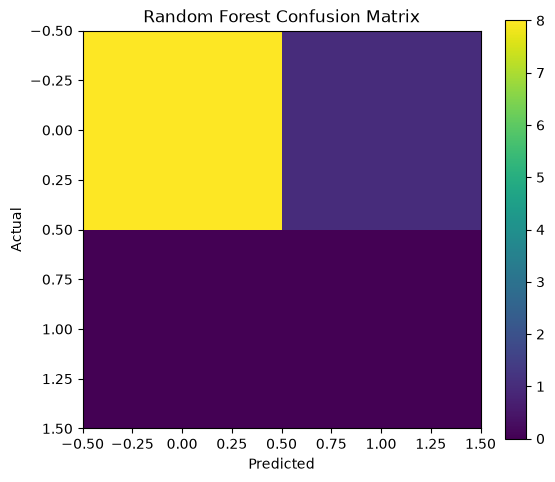

In [53]:
plt.figure(figsize=(6, 5))

plt.imshow(
    rf_cm
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.colorbar()

plt.tight_layout()

plt.show()

In [54]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probabilities
)

gb_fpr, gb_tpr, _ = roc_curve(
    y_test,
    gb_probabilities
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1364: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1364: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1364: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


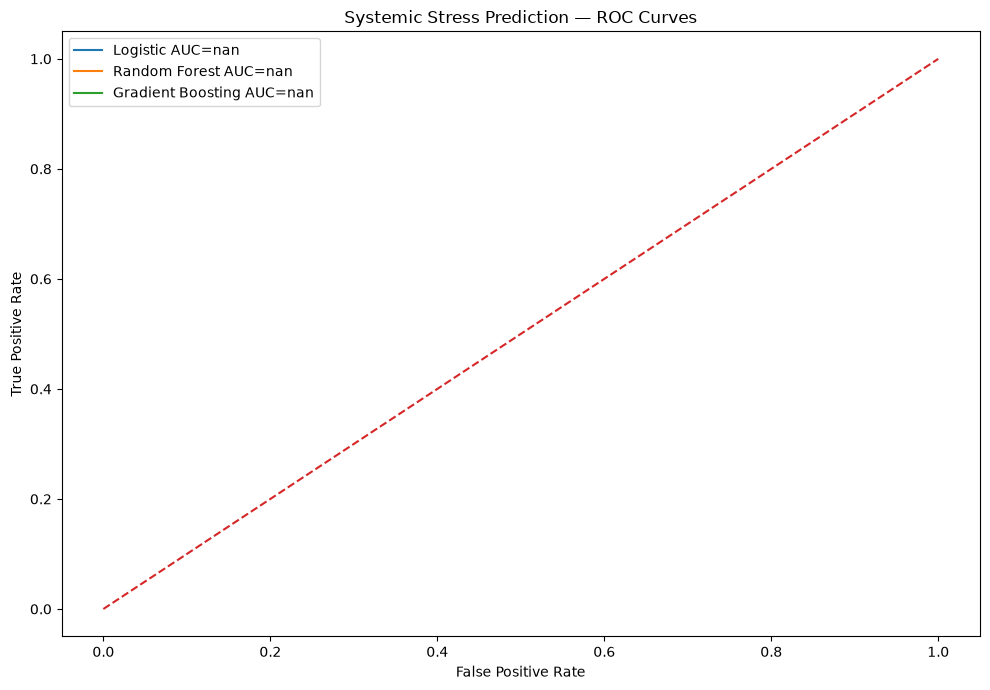

In [55]:
plt.figure(figsize=(10, 7))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic AUC={logistic_results['roc_auc']:.3f}"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest AUC={rf_results['roc_auc']:.3f}"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f"Gradient Boosting AUC={gb_results['roc_auc']:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Systemic Stress Prediction — ROC Curves"
)

plt.legend()

plt.tight_layout()

plt.show()

In [56]:
logistic_precision, logistic_recall, _ = (
    precision_recall_curve(
        y_test,
        logistic_probabilities
    )
)

rf_precision, rf_recall, _ = (
    precision_recall_curve(
        y_test,
        rf_probabilities
    )
)

gb_precision, gb_recall, _ = (
    precision_recall_curve(
        y_test,
        gb_probabilities
    )
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


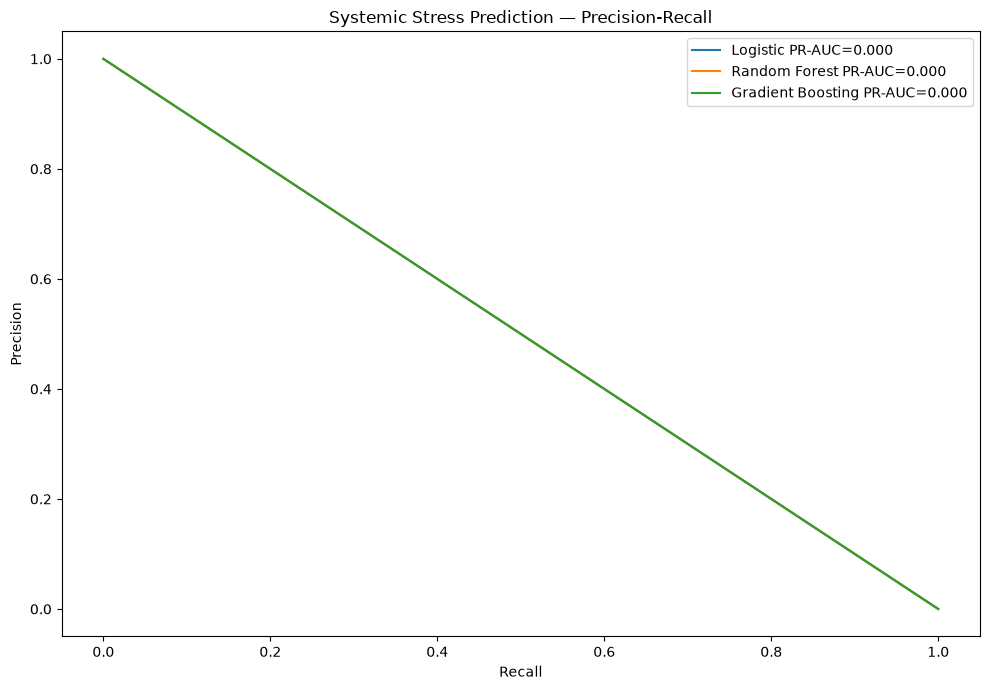

In [57]:
plt.figure(figsize=(10, 7))

plt.plot(
    logistic_recall,
    logistic_precision,
    label=f"Logistic PR-AUC={logistic_results['pr_auc']:.3f}"
)

plt.plot(
    rf_recall,
    rf_precision,
    label=f"Random Forest PR-AUC={rf_results['pr_auc']:.3f}"
)

plt.plot(
    gb_recall,
    gb_precision,
    label=f"Gradient Boosting PR-AUC={gb_results['pr_auc']:.3f}"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Systemic Stress Prediction — Precision-Recall"
)

plt.legend()

plt.tight_layout()

plt.show()

In [58]:
rf_importance = pd.DataFrame({

    "feature": features_full,

    "importance":
        rf_model.feature_importances_

})

In [59]:
rf_importance = (
    rf_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

In [60]:
rf_importance.head(15)

,feature,importance
0,market_volatility,0.157739
1,average_clustering,0.112854
2,network_stress_lag_5,0.095890
3,edges,0.069055
4,average_degree,0.066865
5,network_stress_index,0.064049
6,density,0.053900
7,network_stress_lag_10,0.052427
8,network_stress_momentum_5,0.048380
9,network_stress_lag_1,0.045342


In [61]:
top_features = (
    rf_importance
    .head(15)
    .sort_values(
        "importance"
    )
)

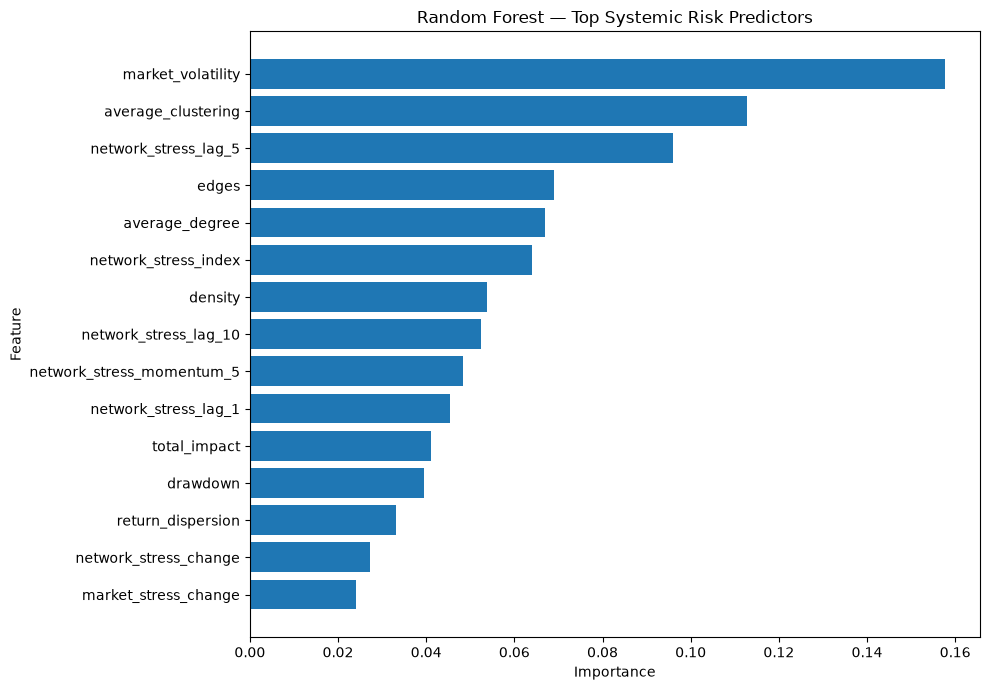

In [62]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest — Top Systemic Risk Predictors"
)

plt.tight_layout()

plt.show()

In [63]:
logistic_coefficients = pd.DataFrame({

    "feature": features_full,

    "coefficient":
        logistic_model.coef_[0]

})

In [64]:
logistic_coefficients[
    "absolute_coefficient"
] = (
    logistic_coefficients[
        "coefficient"
    ].abs()
)

In [65]:
logistic_coefficients = (
    logistic_coefficients
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
)

In [66]:
logistic_coefficients.head(15)

,feature,coefficient,absolute_coefficient
10,affected_companies,-1.196036,1.196036
7,average_clustering,1.006590,1.006590
8,network_stress_index,0.620896,0.620896
9,total_impact,-0.609220,0.609220
17,network_stress_momentum_5,0.519791,0.519791
11,network_stress_lag_1,0.505260,0.505260
13,network_stress_lag_10,-0.398825,0.398825
18,market_stress_momentum_5,0.359083,0.359083
14,network_stress_change,0.239991,0.239991
0,market_volatility,0.164680,0.164680


In [67]:
def run_random_forest_experiment(
    df,
    feature_list,
    target_column="future_stress_event",
    train_ratio=0.80
):

    data = df.dropna(
        subset=feature_list + [
            target_column
        ]
    ).copy()

    data = data.sort_values(
        "date"
    ).reset_index(
        drop=True
    )

    split = int(
        len(data) * train_ratio
    )

    X_train = data[
        feature_list
    ].iloc[:split]

    X_test = data[
        feature_list
    ].iloc[split:]

    y_train = data[
        target_column
    ].iloc[:split].astype(int)

    y_test = data[
        target_column
    ].iloc[split:].astype(int)

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    probabilities = (
        model.predict_proba(
            X_test
        )[:, 1]
    )

    metrics = evaluate_model(
        "Random Forest",
        y_test,
        predictions,
        probabilities
    )

    return (
        model,
        metrics
    )

In [68]:
traditional_model, traditional_results = (
    run_random_forest_experiment(
        phase11_df,
        features_traditional
    )
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [69]:
network_model, network_results_ml = (
    run_random_forest_experiment(
        phase11_df,
        features_network
    )
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [70]:
full_model, full_results = (
    run_random_forest_experiment(
        phase11_df,
        features_full
    )
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [71]:
ablation_results = pd.DataFrame([

    {
        "experiment":
            "Traditional",

        **traditional_results
    },

    {
        "experiment":
            "Traditional + Network",

        **network_results_ml
    },

    {
        "experiment":
            "Full FinGraph-Sentinel",

        **full_results
    }
])

In [72]:
ablation_results = (
    ablation_results
    .drop(
        columns=["model"]
    )
)

In [73]:
ablation_results

,experiment,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Traditional,0.777778,0.0,0.0,0.0,NaN,0.0
1,Traditional + Network,0.888889,0.0,0.0,0.0,NaN,0.0
2,Full FinGraph-Sentinel,0.888889,0.0,0.0,0.0,NaN,0.0


In [74]:
traditional_auc = (
    ablation_results
    .loc[
        ablation_results["experiment"]
        == "Traditional",
        "roc_auc"
    ]
    .iloc[0]
)

full_auc = (
    ablation_results
    .loc[
        ablation_results["experiment"]
        == "Full FinGraph-Sentinel",
        "roc_auc"
    ]
    .iloc[0]
)

In [75]:
auc_improvement = (
    full_auc -
    traditional_auc
)

In [76]:
print(
    f"ROC-AUC improvement: "
    f"{auc_improvement:.4f}"
)

ROC-AUC improvement: nan


In [77]:
phase10_comparison = pd.read_csv(
    RESULTS_PATH /
    "phase10_model_comparison.csv"
)

In [78]:
phase10_comparison

,Model,Precision,Recall,F1,ROC-AUC
0,Volatility,0.8,0.2500,0.380952,0.807692
1,Drawdown,0.6,0.1875,0.285714,0.574519
2,Network,1.0,0.3125,0.476190,0.742788
3,FinGraph-Sentinel EWS,1.0,0.3125,0.476190,0.677885


In [79]:
phase11_summary = pd.DataFrame([

    {
        "model":
            "Phase 10 Volatility",
        "precision":
            phase10_comparison[
                phase10_comparison["Model"]
                == "Volatility"
            ]["Precision"].iloc[0],
        "recall":
            phase10_comparison[
                phase10_comparison["Model"]
                == "Volatility"
            ]["Recall"].iloc[0],
        "f1":
            phase10_comparison[
                phase10_comparison["Model"]
                == "Volatility"
            ]["F1"].iloc[0],
        "roc_auc":
            phase10_comparison[
                phase10_comparison["Model"]
                == "Volatility"
            ]["ROC-AUC"].iloc[0]
    },

    {
        "model":
            "Phase 10 FinGraph EWS",
        "precision":
            phase10_comparison[
                phase10_comparison["Model"]
                == "FinGraph-Sentinel EWS"
            ]["Precision"].iloc[0],
        "recall":
            phase10_comparison[
                phase10_comparison["Model"]
                == "FinGraph-Sentinel EWS"
            ]["Recall"].iloc[0],
        "f1":
            phase10_comparison[
                phase10_comparison["Model"]
                == "FinGraph-Sentinel EWS"
            ]["F1"].iloc[0],
        "roc_auc":
            phase10_comparison[
                phase10_comparison["Model"]
                == "FinGraph-Sentinel EWS"
            ]["ROC-AUC"].iloc[0]
    },

    {
        "model":
            "Phase 11 Logistic Regression",
        "precision":
            logistic_results["precision"],
        "recall":
            logistic_results["recall"],
        "f1":
            logistic_results["f1"],
        "roc_auc":
            logistic_results["roc_auc"]
    },

    {
        "model":
            "Phase 11 Random Forest",
        "precision":
            rf_results["precision"],
        "recall":
            rf_results["recall"],
        "f1":
            rf_results["f1"],
        "roc_auc":
            rf_results["roc_auc"]
    },

    {
        "model":
            "Phase 11 Gradient Boosting",
        "precision":
            gb_results["precision"],
        "recall":
            gb_results["recall"],
        "f1":
            gb_results["f1"],
        "roc_auc":
            gb_results["roc_auc"]
    }
])

In [80]:
phase11_summary

,model,precision,recall,f1,roc_auc
0,Phase 10 Volatility,0.8,0.2500,0.380952,0.807692
1,Phase 10 FinGraph EWS,1.0,0.3125,0.476190,0.677885
2,Phase 11 Logistic Regression,0.0,0.0000,0.000000,NaN
3,Phase 11 Random Forest,0.0,0.0000,0.000000,NaN
4,Phase 11 Gradient Boosting,0.0,0.0000,0.000000,NaN


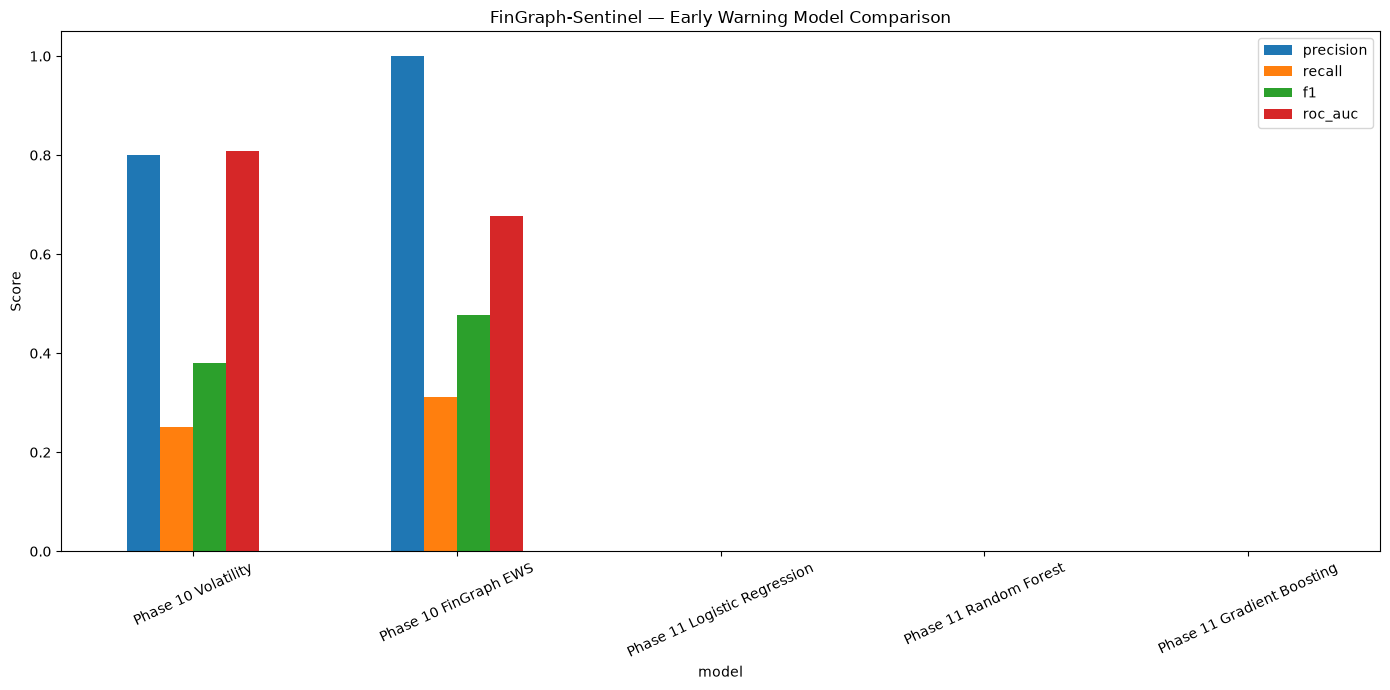

In [81]:
phase11_summary.set_index(
    "model"
)[
    [
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "FinGraph-Sentinel — Early Warning Model Comparison"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=25
)

plt.tight_layout()

plt.show()

In [82]:
permutation = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

c:\Users\ADMIN\FinGraph-Sentinel\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [83]:
permutation_df = pd.DataFrame({

    "feature":
        features_full,

    "importance_mean":
        permutation.importances_mean,

    "importance_std":
        permutation.importances_std

})

In [84]:
permutation_df = (
    permutation_df
    .sort_values(
        "importance_mean",
        ascending=False
    )
)

In [85]:
permutation_df.head(15)

,feature,importance_mean,importance_std
0,market_volatility,NaN,NaN
1,drawdown,NaN,NaN
2,return_dispersion,NaN,NaN
3,market_stress_index,NaN,NaN
4,edges,NaN,NaN
5,density,NaN,NaN
6,average_degree,NaN,NaN
7,average_clustering,NaN,NaN
8,network_stress_index,NaN,NaN
9,total_impact,NaN,NaN


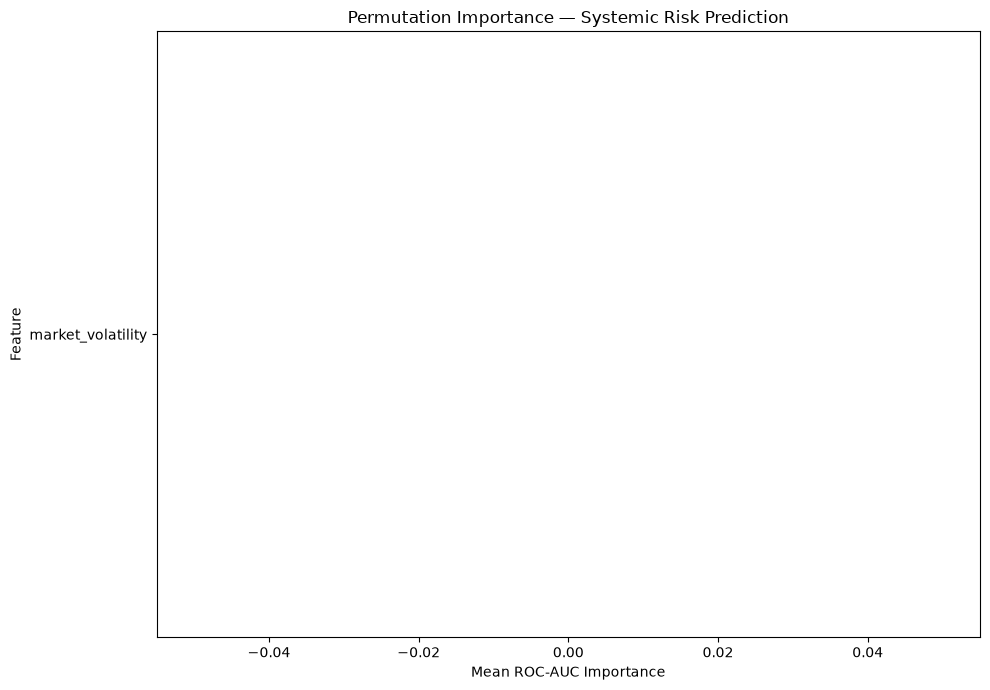

In [86]:
top_permutation = (
    permutation_df
    .head(15)
    .sort_values(
        "importance_mean"
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_permutation["feature"],
    top_permutation["importance_mean"]
)

plt.xlabel(
    "Mean ROC-AUC Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Permutation Importance — Systemic Risk Prediction"
)

plt.tight_layout()

plt.show()

In [87]:
phase11_summary.to_csv(
    RESULTS_PATH /
    "phase11_model_comparison.csv",
    index=False
)

In [88]:
ablation_results.to_csv(
    RESULTS_PATH /
    "phase11_ablation_results.csv",
    index=False
)

In [89]:
rf_importance.to_csv(
    RESULTS_PATH /
    "phase11_random_forest_importance.csv",
    index=False
)

In [90]:
logistic_coefficients.to_csv(
    RESULTS_PATH /
    "phase11_logistic_coefficients.csv",
    index=False
)

In [91]:
permutation_df.to_csv(
    RESULTS_PATH /
    "phase11_permutation_importance.csv",
    index=False
)

In [92]:
prediction_df = phase11_df[
    [
        "date",
        "future_stress_event"
    ]
].iloc[
    split_index:
].copy()

In [93]:
prediction_df[
    "logistic_probability"
] = logistic_probabilities

prediction_df[
    "random_forest_probability"
] = rf_probabilities

prediction_df[
    "gradient_boosting_probability"
] = gb_probabilities

prediction_df[
    "random_forest_prediction"
] = rf_predictions

In [94]:
prediction_df.to_csv(
    RESULTS_PATH /
    "phase11_test_predictions.csv",
    index=False
)

In [95]:
print("=" * 70)
print("FIN-GRAPH-SENTINEL — PHASE 11 VALIDATION")
print("=" * 70)

print(
    "\nDataset:",
    phase11_df.shape
)

print(
    "\nTrain observations:",
    len(X_train)
)

print(
    "Test observations:",
    len(X_test)
)

print(
    "\nTrain period:",
    train_dates.min(),
    "→",
    train_dates.max()
)

print(
    "Test period:",
    test_dates.min(),
    "→",
    test_dates.max()
)

print(
    "\nMODEL PERFORMANCE"
)

print(
    phase11_summary.to_string(
        index=False
    )
)

print(
    "\nTOP FEATURES"
)

print(
    rf_importance.head(10).to_string(
        index=False
    )
)

print(
    "\nABLATION RESULTS"
)

print(
    ablation_results.to_string(
        index=False
    )
)

print("=" * 70)

FIN-GRAPH-SENTINEL — PHASE 11 VALIDATION

Dataset: (42, 36)

Train observations: 33
Test observations: 9

Train period: 2024-08-14 04:00:00 → 2025-11-21 05:00:00
Test period: 2025-12-08 05:00:00 → 2026-04-06 04:00:00

MODEL PERFORMANCE
                       model  precision  recall       f1  roc_auc
         Phase 10 Volatility        0.8  0.2500 0.380952 0.807692
       Phase 10 FinGraph EWS        1.0  0.3125 0.476190 0.677885
Phase 11 Logistic Regression        0.0  0.0000 0.000000      NaN
      Phase 11 Random Forest        0.0  0.0000 0.000000      NaN
  Phase 11 Gradient Boosting        0.0  0.0000 0.000000      NaN

TOP FEATURES
                  feature  importance
        market_volatility    0.157739
       average_clustering    0.112854
     network_stress_lag_5    0.095890
                    edges    0.069055
           average_degree    0.066865
     network_stress_index    0.064049
                  density    0.053900
    network_stress_lag_10    0.052427
network_stre